In [1]:
!python -V

Python 3.9.12


In [2]:
import pandas as pd
import numpy as np
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

In [3]:
import mlflow 

mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("nyc-taxi-experiment")

2026/07/20 23:51:00 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/20 23:51:00 INFO mlflow.store.db.utils: Updating database tables
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.


<Experiment: artifact_location='/workspaces/mlops-zoomcamp/02-experiment-tracking/mlruns/1', creation_time=1784583723573, experiment_id='1', last_update_time=1784583723573, lifecycle_stage='active', name='nyc-taxi-experiment', tags={}>

In [4]:
def read_dataframe(filename):
    if filename.endswith('.csv'):
        df = pd.read_csv(filename)

        df.lpep_dropoff_datetime = pd.to_datetime(df.lpep_dropoff_datetime)
        df.lpep_pickup_datetime = pd.to_datetime(df.lpep_pickup_datetime)
    elif filename.endswith('.parquet'):
        df = pd.read_parquet(filename)

    df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
    df['duration_t'] = df.duration.apply(lambda td: td.total_seconds() / 60)

    df = df[(df.duration_t >= 0) & (df.duration_t <= 60)]
    
    df = df[df.trip_type.notna()]
    
    df['lpep_pickup_hour']=df['lpep_pickup_datetime'].dt.hour
    
    df['lpep_pickup_dayofweek']=df['lpep_pickup_datetime'].dt.dayofweek
    
    df['lpep_pickup_weekend']=df['lpep_pickup_dayofweek'].apply(lambda x: 'weekend' if x >= 5 else 'weekday')
    
    df['lpep_pickup_weekend_hour'] = df['lpep_pickup_weekend'].astype(str) + '_' + df['lpep_pickup_hour'].astype(str)
    
    df['PU_DO_LocationID'] = df['PULocationID'].astype(str) + '_' + df['DOLocationID'].astype(str)

    categorical = ['lpep_pickup_hour','PU_DO_LocationID']
    df[categorical] = df[categorical].astype(str)
    
    df['congestion_surcharge'].fillna(0, inplace=True)
    df['improvement_surcharge'].fillna(0, inplace=True)
    
    return df

In [5]:
df_train = read_dataframe('data/green_tripdata_2024-01.parquet')
df_val = read_dataframe('data/green_tripdata_2024-02.parquet')

In [6]:
len(df_train), len(df_val)

(52656, 50124)

In [7]:
df_train.duration_t.describe()

count    52656.000000
mean        12.976168
std          8.773712
min          0.000000
25%          7.100000
50%         11.100000
75%         16.550000
max         59.983333
Name: duration_t, dtype: float64

In [8]:
df_train.tail()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,payment_type,trip_type,congestion_surcharge,duration,duration_t,lpep_pickup_hour,lpep_pickup_dayofweek,lpep_pickup_weekend,lpep_pickup_weekend_hour,PU_DO_LocationID
53131,2,2024-01-31 23:48:18,2024-02-01 00:01:52,N,1.0,130,218,2.0,3.28,16.3,...,1.0,1.0,0.0,0 days 00:13:34,13.566667,23,2,weekday,weekday_23,130_218
53132,2,2024-01-31 23:14:12,2024-01-31 23:25:41,N,1.0,130,219,1.0,4.20,19.8,...,1.0,1.0,0.0,0 days 00:11:29,11.483333,23,2,weekday,weekday_23,130_219
53133,2,2024-01-31 23:19:14,2024-01-31 23:19:27,N,5.0,181,181,2.0,0.00,74.0,...,1.0,2.0,0.0,0 days 00:00:13,0.216667,23,2,weekday,weekday_23,181_181
53134,2,2024-01-31 23:22:53,2024-01-31 23:31:25,N,1.0,74,116,1.0,2.20,12.1,...,1.0,1.0,0.0,0 days 00:08:32,8.533333,23,2,weekday,weekday_23,74_116
53135,2,2024-01-31 23:22:45,2024-01-31 23:24:51,N,5.0,41,41,1.0,0.42,10.0,...,2.0,2.0,0.0,0 days 00:02:06,2.100000,23,2,weekday,weekday_23,41_41


In [9]:
df_train.lpep_pickup_weekend_hour.value_counts()

weekday_17    3513
weekday_18    3382
weekday_16    3286
weekday_15    3019
weekday_19    2634
weekday_14    2549
weekday_9     2296
weekday_13    2284
weekday_10    2202
weekday_8     2192
weekday_11    2180
weekday_12    2159
weekday_20    1932
weekday_7     1906
weekday_21    1400
weekday_22    1142
weekday_23     861
weekend_15     836
weekend_17     824
weekend_18     818
weekend_16     808
weekend_14     772
weekend_19     758
weekday_6      698
weekend_13     696
weekend_12     593
weekend_11     580
weekday_0      577
weekend_20     568
weekend_21     481
weekend_10     476
weekend_0      393
weekend_9      391
weekend_22     383
weekday_1      369
weekend_23     352
weekend_1      348
weekend_2      272
weekend_8      254
weekday_2      231
weekend_3      226
weekday_5      214
weekend_7      187
weekday_3      156
weekend_4      141
weekday_4      140
weekend_6      109
weekend_5       68
Name: lpep_pickup_weekend_hour, dtype: int64

In [10]:
categorical = ['PU_DO_LocationID','lpep_pickup_weekend_hour', 'trip_type', 'congestion_surcharge', 'improvement_surcharge']
numerical = ['trip_distance']

dv = DictVectorizer()

train_dicts = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)

val_dicts = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dicts)

In [11]:
target = 'duration_t'
y_train = df_train[target].values
y_val = df_val[target].values

In [15]:
with mlflow.start_run():

    mlflow.set_tag("developer", "sameh")
    mlflow.log_param("train-data-path", "data/green_tripdata_2024-01.parquet")
    mlflow.log_param("val-data-path", "data/green_tripdata_2024-02.parquet")
    mlflow.log_param("model_type", "linear_regression")


    #alpha=0.00001
    #mlflow.log_param("alpha", 0.00001)

    #lr = Ridge(alpha=alpha)

    lr = LinearRegression()
    lr.fit(X_train, y_train)

    y_pred = lr.predict(X_val)

    rmse=np.sqrt(mean_squared_error(y_val, y_pred))
    rmse
    mlflow.log_metric("rmse", rmse)

/home/codespace/anaconda3/lib/python3.9/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/home/codespace/anaconda3/lib/python3.9/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


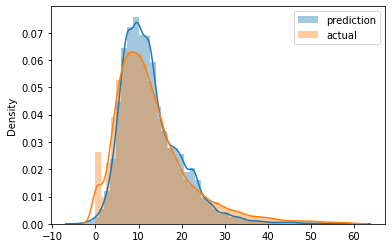

In [16]:
sns.distplot(y_pred, label='prediction')
sns.distplot(y_val, label='actual')

plt.legend()

In [17]:
import xgboost as xgb

In [18]:
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from hyperopt.pyll import scope

In [19]:
train = xgb.DMatrix(X_train, label=y_train)
valid = xgb.DMatrix(X_val, label=y_val)

In [ ]:
def objective(params):
    with mlflow.start_run():
        mlflow.set_tag("developer", "sameh")
        mlflow.log_param("train-data-path", "data/green_tripdata_2024-01.parquet")
        mlflow.log_param("val-data-path", "data/green_tripdata_2024-02.parquet")
        mlflow.log_param("model_type", "xgboost")
        mlflow.log_params(params)
        booster = xgb.train(
            params=params,
            dtrain=train,
            num_boost_round=100,
            evals=[(valid, 'validation')],
            early_stopping_rounds=5
        )
        y_pred = booster.predict(valid)
        rmse = np.sqrt(mean_squared_error(y_val, y_pred))
        mlflow.log_metric("rmse", rmse)

    return {'loss': rmse, 'status': STATUS_OK}

: 

In [ ]:
search_space = {
    'max_depth': scope.int(hp.quniform('max_depth', 4, 100, 1)),
    'learning_rate': hp.loguniform('learning_rate', -3, 0),
    'reg_alpha': hp.loguniform('reg_alpha', -5, -1),
    'reg_lambda': hp.loguniform('reg_lambda', -6, -1),
    'min_child_weight': hp.loguniform('min_child_weight', -1, 3),
    'objective': 'reg:linear',
    'seed': 42
}

best_result = fmin(
    fn=objective,
    space=search_space,
    algo=tpe.suggest,
    max_evals=5,
    trials=Trials()
)

  0%|          | 0/5 [00:00<?, ?trial/s, best loss=?]

/home/codespace/anaconda3/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [23:51:07] WARNING: /workspace/src/objective/regression_obj.cu:227: reg:linear is now deprecated in favor of reg:squarederror.
  warnings.warn(smsg, UserWarning)



[0]	validation-rmse:7.52088                          
[1]	validation-rmse:6.58359                          
  0%|          | 0/5 [00:15<?, ?trial/s, best loss=?]